In [346]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional
from itertools import product
import matplotlib.lines as mlines

from utils import SECTORS, DR_PRICES, NG_PRICES, NAT_GAS_NICE_NAMES, get_dataframe, get_scenario_name

In [347]:
# User defined variables
METHOD = "dynamic" # "static" | "dynamic"
REGION = "new_england" # "caiso" | "new_england" | "caiso_cc"

In [348]:
# Path handling (DO NOT CHANGE)
FIGURES_BASE = Path("..","figures","netload_timeseries")
FIGURES_METHOD = Path(FIGURES_BASE, REGION, METHOD)
BUFFER_DAYS = 6 if REGION == "new_negland" else 3

In [349]:
def get_net_loads(region: str, scenario: str, sector: Optional[str] = None, dr_price: Optional[str] = None, method: Optional[str] = None) -> pd.Series:
    scenario = get_scenario_name(scenario=scenario, sector=sector, dr_price=dr_price)
    df = get_dataframe(region=region, method=method, scenario=scenario, sector=sector, dr_price=dr_price, result="peakiness")
    return df[["Net_Load_MW"]].rename(columns={"Net_Load_MW":scenario}).squeeze()

In [350]:
def get_base_net_load(region: str, scenario: str, buffer_days: int = 1) -> pd.DataFrame:
    
    def add_buffer(data: int | list[int], buffer: int) -> list[int]:
        if not data:
            return []
        if isinstance(data, int):
            data = [data]
        start = min(data) - buffer
        end = max(data) + buffer
        return list(range(start, end + 1))

    df = get_net_loads(region=region, scenario=scenario)
    df.index = pd.to_datetime(df.index)
    daysofyear = add_buffer(df.index[0].dayofyear, buffer_days)
    df = df[df.index.dayofyear.isin(daysofyear)]
    return df.sort_index().to_frame(name="No DR")

In [351]:
def get_scenario_net_load(region: str, scenario: str, sector: str, dr_price: str, method: str, idx: pd.DatetimeIndex) -> pd.DataFrame:
    df = get_net_loads(region=region, scenario=scenario, sector=sector, dr_price=dr_price, method=method)
    df.index = pd.to_datetime(df.index)
    df = df.loc[idx].sort_index().to_frame(name=f"{sector}-{dr_price}")
    return df

In [352]:
def get_data(buffer_days: int = 0) -> dict[str,pd.DataFrame]:
    data = {}
    for ng_price in NG_PRICES:
        dfs = []
        dfs.append(get_base_net_load(region=REGION, scenario=ng_price, buffer_days=buffer_days))
        idx = dfs[0].index
        for sector, price in product(SECTORS, DR_PRICES):
            dfs.append(get_scenario_net_load(region=REGION, scenario=ng_price, sector=sector, dr_price=price, method=METHOD, idx=idx))
        data[ng_price] = pd.concat(dfs, axis=1)
    return data

In [353]:
def generate_net_load_deviations(
    ng_price: str, include_title: bool = True, **kwargs
) -> tuple[plt.figure, plt.axes]:
    buffer_days = kwargs.get("buffer_days", 0)
    data = get_data(buffer_days=buffer_days)

    ncols = 1
    nrows = 1

    color_map = {
        "base": "k",
        "e": "tab:purple",
        "t": "tab:orange",
        "et": "tab:green",
    }

    linestyle_map = {
        "base": "-",
        "high": "-",
        "mid": "--",
        "low": "-.",
        "vlow": ":",
    }

    fig, ax = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))

    title = kwargs.get("title", "")
    if title:
        fig.suptitle(title, fontsize=20)

    df = data[ng_price]

    for col in df.columns:
        if col == "No DR":
            sector = "base"
            price = "base"
            label = "No DR"
        else:
            sector = col.split("-")[0]
            price = col.split("-")[1]
            label = f"{sector}-{price}"

        color = color_map[sector]
        linestyle = linestyle_map[price]

        if col == "No DR":
            df[col].plot(ax=ax, label=label, color=color, linestyle=linestyle, zorder=100)
        else:
            df[col].plot(ax=ax, label=label, color=color, linestyle=linestyle)

    handles, labels = ax.get_legend_handles_labels()
    
    ax.set_xlabel("")
    
    max_load = df.max().max()
    max_load = round(max_load * 1.1)
    min_load = df.min().min()
    min_load = 0 if min_load > 0 else round(min_load * 1.1)
    ax.set_ylim(min_load, max_load)

    # for custom linewidth
    legend_handles = [
        mlines.Line2D(
            [],
            [],
            color=handle.get_color(),
            linewidth=2,
            linestyle=handle.get_linestyle(),
        )
        for handle in handles
    ]

    fig.legend(
        legend_handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1, 0.5),  # right side
        ncol=1,
        frameon=False,
        fontsize=14,
    )
    
    ax.tick_params(axis="both", labelsize=12)

    if include_title:
        fig.suptitle(
            f"{NAT_GAS_NICE_NAMES[ng_price]} Net Load Curve", fontsize=20
        )
    # fig.supxlabel("Timestamp", fontsize=18)
    fig.supylabel("Net Load (MW)", fontsize=18)

    fig.tight_layout(rect=[0, 0, 1, 0.99])

    return fig, ax

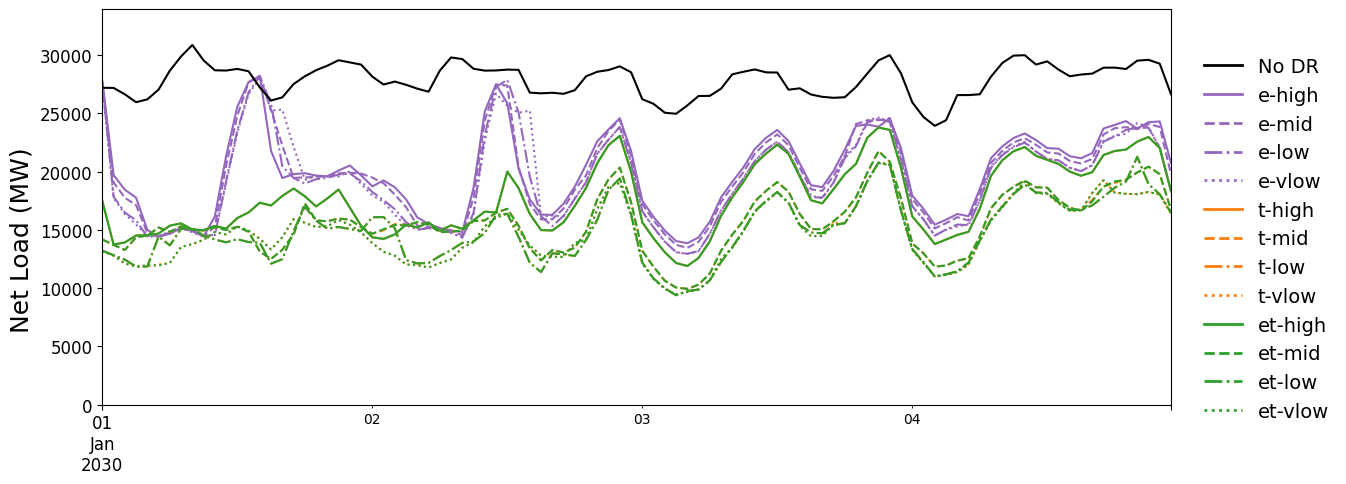

In [354]:
fig, _ = generate_net_load_deviations("lgas", include_title=False, buffer_days=BUFFER_DAYS)
save_f = Path(FIGURES_METHOD, "lgas.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")

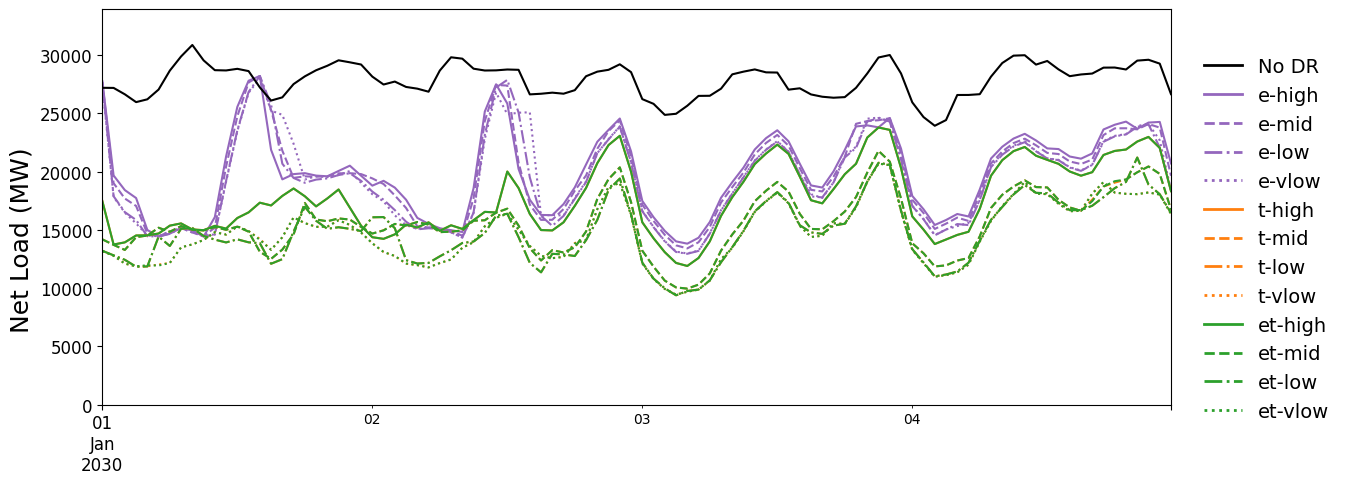

In [355]:
fig, _ = generate_net_load_deviations("mgas", include_title=False, buffer_days=BUFFER_DAYS)
save_f = Path(FIGURES_METHOD, "mgas.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")

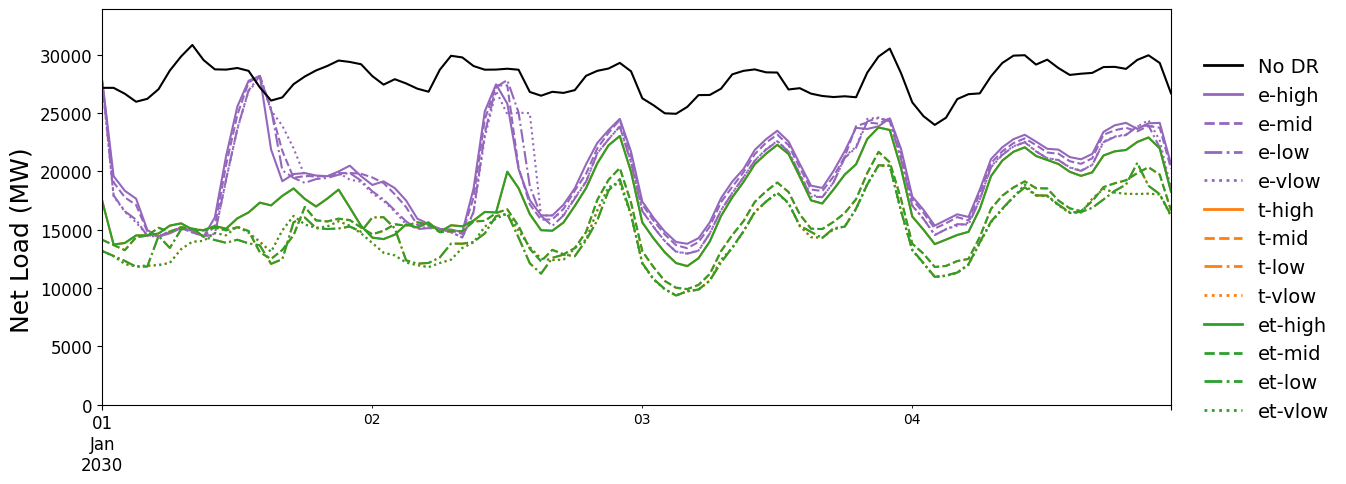

In [356]:
fig, _ = generate_net_load_deviations("hgas", include_title=False, buffer_days=BUFFER_DAYS)
save_f = Path(FIGURES_METHOD, "hgas.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")